# 11 — Conceitos e Famílias com Janela 24h/8h

## Objetivo

Reavaliar representações de alarme na nova configuração temporal de desenvolvimento:

- observação: 24 horas;
- horizonte: 8 horas;
- gap principal: 900s;
- sensibilidade: 450s e 600s.

Modelos comparados:

1. `RF_ids`;
2. `RF_ids_textual`;
3. `RF_ids_manual_family`;
4. `RF_ids_textual_manual_family`.

## Limite metodológico

O gap 900s segue como referência conservadora. Os gaps 450s e 600s são sensibilidade porque 450s
venceu formalmente na validação do notebook 10 e 600s teve melhor F2 no teste. A decisão final não
deve ser tomada apenas pelo melhor resultado do teste.

Para viabilizar a comparação com muitas features, as features da janela de 24h são calculadas pela
soma dos três buckets de 8h anteriores à previsão. Essa aproximação preserva a estrutura temporal e
evita range joins grandes para cada família/conceito.

In [1]:
from pathlib import Path
import re
import time
import unicodedata

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score, balanced_accuracy_score, f1_score, fbeta_score,
    precision_score, recall_score, roc_auc_score,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 250)
pd.set_option("display.max_rows", 250)

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
BASE = ROOT / "data" / "raw" / "Base"
TEL_GLOB = str(BASE / "datasets" / "telemetria" / "telemetry_*.parquet")

OBSERVATION_HOURS = 24
HORIZON_HOURS = 8
PRIMARY_GAP = 900
SENSITIVITY_GAPS = [450, 600]
GAP_CANDIDATES_SECONDS = [PRIMARY_GAP] + SENSITIVITY_GAPS
TOP_ALARM_IDS = 200
TOP_TEXT_CONCEPTS = 200
TOP_MANUAL_FAMILIES = 60

LOOP_TAG = "PE3798"
LOOP_DAY = pd.Timestamp("2025-06-29")
LOOP_ALARM_IDS = (1241582851, 1241582848)
MISSING_START = pd.Timestamp("2025-05-31 00:00:00")
MISSING_END = pd.Timestamp("2025-06-01 00:00:00")

con = duckdb.connect()
con.execute("SET threads=4")
con.execute("SET preserve_insertion_order=false")
con.execute(f"CREATE OR REPLACE VIEW tel AS SELECT * FROM read_parquet('{TEL_GLOB}', union_by_name=true)")

def query(sql):
    return con.sql(sql).df()

def normalize_alarm_name(value):
    if pd.isna(value):
        return "SEM_DESCRICAO"
    text = str(value).strip().upper()
    text = unicodedata.normalize("NFKD", text)
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    text = re.sub(r"\s*\(L-?\d+\)\s*$", "", text)
    text = re.sub(r"[^A-Z0-9]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text or "SEM_DESCRICAO"

def manual_family(text):
    t = normalize_alarm_name(text)
    if t.startswith("OEM INTERFACE"):
        return "COMUNICACAO_INTERFACE"
    if t.startswith("RX CHANNEL") and "NOT RECEIVING MESSAGES" in t:
        return "COMUNICACAO_INTERFACE"
    if "TIRE TAG TIMEOUT" in t:
        return "PNEUS_MONITORAMENTO"
    if (
        t in {"DIPPER", "CYCLE", "BODY UP", "LOAD"}
        or "PAYLOAD OVERLOAD" in t
        or "TRUCK LOAD WEIGHT" in t
        or "BUCKET LOAD WEIGHT" in t
        or "BUCKET ANGLE" in t
        or "HOIST" in t
        or "LIFT ARMS" in t
        or "DUMP WHEEL" in t
        or "ROLLBACK" in t
    ):
        return "OPERACAO_CARGA_BASCULAMENTO"
    if "COOLANT LEVEL" in t or "ARREF" in t:
        return "MOTOR_ARREFECIMENTO"
    if "ENGINE PRELUBE" in t or "OLEO MOTOR" in t:
        return "MOTOR_LUBRIFICACAO"
    if "ENGINE AT HIGH THROTTLE" in t or "ENGINE AT LOW THROTTLE" in t or "EXHAUST TEMPERATURE" in t or "TEMP EXAUST" in t:
        return "MOTOR_OPERACAO"
    if "PARKING BRAKE" in t or "FREIO" in t or "BRAKE" in t:
        return "FREIOS"
    if "STEERING" in t or "DIRECAO" in t or "STEER" in t:
        return "DIRECAO"
    if "TRANSMISSION OIL" in t or "DIFFERENTIAL" in t or "FINAL DRIVE" in t:
        return "TREM_FORCA"
    if "SYSTEM VOLTAGE" in t or "VOLTAGE" in t or "VOLTAGEM" in t or "BATTERY" in t:
        return "ELETRICO"
    if "VEHICLE SPEED" in t or "LIMITE DE VELOCIDADE" in t:
        return "OPERACAO_VELOCIDADE"
    if "TESTE OP ENTRADA" in t:
        return "TESTE_OPERACIONAL"
    return "OUTROS"

print(f"Raiz do projeto: {ROOT}")
print(f"Gap principal: {PRIMARY_GAP}s")
print(f"Sensibilidade: {SENSITIVITY_GAPS}")

Raiz do projeto: /home/f_szekut/projects/vale_correct
Gap principal: 900s
Sensibilidade: [450, 600]


## 1. Camada analítica congelada

In [2]:
start = time.time()
con.execute(
    f'''
    CREATE OR REPLACE TEMP TABLE analytic_events AS
    SELECT
        min(Id_Eventos_Telemetria) AS Id_Eventos_Telemetria_referencia,
        Data_Evento, Inicio_Turno, Fim_Turno, Dia, Localidade, TAG, Tag_Frota, Tipo,
        Nome_Operador_Anon, Matricula_Operador_Hash, Id_Alarme, Alarme,
        Id_Criticidade, Criticidade, Valor, Classe, Is_Dont_Go,
        count(*) AS ids_evento_no_grupo
    FROM tel
    WHERE NOT (
        TAG = '{LOOP_TAG}'
        AND CAST(Data_Evento AS DATE) = DATE '{LOOP_DAY.date()}'
        AND Id_Alarme IN {LOOP_ALARM_IDS}
    )
    GROUP BY
        Data_Evento, Inicio_Turno, Fim_Turno, Dia, Localidade, TAG, Tag_Frota, Tipo,
        Nome_Operador_Anon, Matricula_Operador_Hash, Id_Alarme, Alarme,
        Id_Criticidade, Criticidade, Valor, Classe, Is_Dont_Go
    '''
)

base_audit = query(
    '''
    SELECT
        count(*) AS registros_analiticos,
        sum(ids_evento_no_grupo - 1) AS duplicatas_retiradas,
        sum(Is_Dont_Go) AS linhas_dont_go
    FROM analytic_events
    '''
)
base_audit["tempo_s"] = round(time.time() - start, 1)
display(base_audit)

,registros_analiticos,duplicatas_retiradas,linhas_dont_go,tempo_s
0,35608094,265564.0,19941.0,16.4


## 2. Funções do experimento

In [3]:
def build_sequences(gap_seconds):
    con.execute(
        f'''
        CREATE OR REPLACE TEMP TABLE alarm_sequences AS
        WITH ordered AS (
            SELECT *,
                   lag(Data_Evento) OVER (
                       PARTITION BY TAG, Id_Alarme ORDER BY Data_Evento, Id_Eventos_Telemetria_referencia
                   ) AS evento_anterior
            FROM analytic_events
        ), flagged AS (
            SELECT *,
                   CASE
                       WHEN evento_anterior IS NULL THEN 1
                       WHEN date_diff('millisecond', evento_anterior, Data_Evento)
                            > {gap_seconds * 1000} THEN 1
                       ELSE 0
                   END AS nova_sequencia
            FROM ordered
        ), numbered AS (
            SELECT *,
                   sum(nova_sequencia) OVER (
                       PARTITION BY TAG, Id_Alarme
                       ORDER BY Data_Evento, Id_Eventos_Telemetria_referencia
                       ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
                   ) AS numero_sequencia
            FROM flagged
        )
        SELECT
            TAG, any_value(Tag_Frota) AS Tag_Frota, any_value(Tipo) AS Tipo,
            Id_Alarme, any_value(Alarme) AS Alarme,
            numero_sequencia,
            min(Data_Evento) AS inicio,
            max(Data_Evento) AS fim,
            date_diff('millisecond', min(Data_Evento), max(Data_Evento)) AS duracao_ms,
            count(*) AS registros_analiticos,
            sum(ids_evento_no_grupo) AS registros_brutos_representados,
            max(Is_Dont_Go) AS is_dont_go,
            max(CASE WHEN Id_Criticidade = 1 THEN 1 ELSE 0 END) AS possui_critico,
            max(CASE WHEN Classe = 'Activate' THEN 1 ELSE 0 END) AS possui_activate,
            max(CASE WHEN Classe = 'Inactive' THEN 1 ELSE 0 END) AS possui_inactive,
            max(CASE WHEN Classe IS NULL THEN 1 ELSE 0 END) AS possui_classe_nula
        FROM numbered
        GROUP BY TAG, Id_Alarme, numero_sequencia
        '''
    )
    return query(
        '''
        SELECT
            count(*) AS sequencias,
            sum(is_dont_go) AS sequencias_dont_go,
            avg(registros_analiticos) AS registros_por_sequencia_media,
            max(registros_analiticos) AS maior_sequencia
        FROM alarm_sequences
        '''
    )

def create_alarm_catalog():
    catalog = query(
        '''
        SELECT Id_Alarme, any_value(Alarme) AS Alarme, count(*) AS sequencias
        FROM alarm_sequences
        GROUP BY 1
        ORDER BY sequencias DESC
        '''
    )
    catalog["conceito_textual"] = catalog["Alarme"].map(normalize_alarm_name)
    catalog["familia_manual"] = catalog["Alarme"].map(manual_family)
    con.register("alarm_concepts", catalog[["Id_Alarme", "conceito_textual", "familia_manual"]])
    return catalog

def build_samples():
    con.execute(
        '''
        CREATE OR REPLACE TEMP TABLE sequence_bins AS
        SELECT
            TAG,
            time_bucket(INTERVAL '8 hours', inicio) AS bin_start,
            count(*) AS sequencias_total,
            count(DISTINCT Id_Alarme) AS alarmes_distintos,
            sum(registros_analiticos) AS registros_analiticos,
            sum(registros_brutos_representados) AS registros_brutos_representados,
            avg(duracao_ms) AS duracao_media_ms,
            sum(duracao_ms) AS duracao_soma_ms,
            max(duracao_ms) AS duracao_max_ms,
            max(registros_analiticos) AS maior_sequencia_registros,
            sum(possui_critico) AS sequencias_com_critico,
            sum(possui_activate) AS sequencias_com_activate,
            sum(possui_inactive) AS sequencias_com_inactive,
            sum(possui_classe_nula) AS sequencias_com_classe_nula,
            sum(is_dont_go) AS episodios_dont_go
        FROM alarm_sequences
        GROUP BY 1, 2
        '''
    )
    con.execute(
        f'''
        CREATE OR REPLACE TEMP TABLE sample_grid AS
        WITH tags AS (
            SELECT DISTINCT TAG FROM analytic_events
        ), prediction_bins AS (
            SELECT * FROM generate_series(
                TIMESTAMP '2025-01-01 00:00:00' + INTERVAL '{OBSERVATION_HOURS} hours',
                TIMESTAMP '2025-07-01 00:00:00' - INTERVAL '{HORIZON_HOURS} hours',
                INTERVAL '8 hours'
            ) AS t(prediction_time)
        )
        SELECT
            row_number() OVER () AS sample_id,
            tags.TAG,
            prediction_time - INTERVAL '{OBSERVATION_HOURS} hours' AS feature_start,
            prediction_time,
            prediction_time + INTERVAL '{HORIZON_HOURS} hours' AS target_end
        FROM tags CROSS JOIN prediction_bins
        WHERE prediction_time - INTERVAL '{OBSERVATION_HOURS} hours' >= TIMESTAMP '2025-01-01 00:00:00'
        '''
    )
    samples = query(
        f'''
        WITH feature_agg AS (
            SELECT
                g.sample_id,
                coalesce(sum(b.sequencias_total), 0) AS sequencias_total,
                coalesce(sum(b.alarmes_distintos), 0) AS alarmes_distintos,
                coalesce(sum(b.registros_analiticos), 0) AS registros_analiticos,
                coalesce(sum(b.registros_brutos_representados), 0) AS registros_brutos_representados,
                CASE
                    WHEN coalesce(sum(b.sequencias_total), 0) > 0
                    THEN coalesce(sum(b.duracao_soma_ms), 0) / sum(b.sequencias_total)
                    ELSE 0
                END AS duracao_media_ms,
                coalesce(max(b.duracao_max_ms), 0) AS duracao_max_ms,
                coalesce(max(b.maior_sequencia_registros), 0) AS maior_sequencia_registros,
                coalesce(sum(b.sequencias_com_critico), 0) AS sequencias_com_critico,
                coalesce(sum(b.sequencias_com_activate), 0) AS sequencias_com_activate,
                coalesce(sum(b.sequencias_com_inactive), 0) AS sequencias_com_inactive,
                coalesce(sum(b.sequencias_com_classe_nula), 0) AS sequencias_com_classe_nula
            FROM sample_grid g
            LEFT JOIN sequence_bins b
              ON b.TAG = g.TAG
             AND b.bin_start >= g.feature_start
             AND b.bin_start < g.prediction_time
            GROUP BY 1
        ), target_agg AS (
            SELECT
                g.sample_id,
                coalesce(sum(b.episodios_dont_go), 0) AS episodios_dont_go_target
            FROM sample_grid g
            LEFT JOIN sequence_bins b
              ON b.TAG = g.TAG
             AND b.bin_start >= g.prediction_time
             AND b.bin_start < g.target_end
            GROUP BY 1
        )
        SELECT
            g.TAG, g.feature_start, g.prediction_time, g.target_end,
            f.* EXCLUDE(sample_id),
            y.episodios_dont_go_target,
            CASE WHEN y.episodios_dont_go_target > 0 THEN 1 ELSE 0 END AS target,
            CASE
                WHEN g.feature_start < TIMESTAMP '{MISSING_END}'
                 AND g.target_end > TIMESTAMP '{MISSING_START}'
                THEN 0 ELSE 1
            END AS amostra_valida
        FROM sample_grid g
        JOIN feature_agg f USING(sample_id)
        JOIN target_agg y USING(sample_id)
        ORDER BY g.prediction_time, g.TAG
        '''
    )
    samples = samples[samples["amostra_valida"] == 1].copy()
    tag_profile = query(
        '''
        SELECT TAG, any_value(Tipo) AS Tipo, any_value(Tag_Frota) AS Tag_Frota
        FROM analytic_events
        GROUP BY 1
        '''
    )
    samples = samples.merge(tag_profile, how="left", on="TAG")
    samples = samples.assign(split=np.select(
        [
            samples["prediction_time"] < pd.Timestamp("2025-05-01"),
            samples["prediction_time"] < pd.Timestamp("2025-05-31"),
            samples["prediction_time"] >= pd.Timestamp("2025-06-01"),
        ],
        ["treino", "validacao", "teste"],
        default="fora_do_split",
    ))
    return samples[samples["split"].isin(["treino", "validacao", "teste"])].copy()

def add_alarm_features(samples):
    top_alarm_ids = query(
        f'''
        SELECT Id_Alarme, count(*) AS sequencias
        FROM alarm_sequences
        WHERE inicio < TIMESTAMP '2025-05-01 00:00:00'
        GROUP BY 1
        ORDER BY sequencias DESC, Id_Alarme
        LIMIT {TOP_ALARM_IDS}
        '''
    )["Id_Alarme"].astype(int).tolist()
    alarm_columns = ",\n".join(
        f"sum(CASE WHEN s.Id_Alarme = {alarm_id} THEN 1 ELSE 0 END) AS alarm_{alarm_id}"
        for alarm_id in top_alarm_ids
    )
    con.execute(
        f'''
        CREATE OR REPLACE TEMP TABLE alarm_bin_features AS
        SELECT TAG, time_bucket(INTERVAL '8 hours', inicio) AS bin_start,
               {alarm_columns}
        FROM alarm_sequences s
        GROUP BY 1, 2
        '''
    )
    alarm_features = query(
        f'''
        SELECT g.TAG, g.feature_start,
               {", ".join(f"coalesce(sum(b.alarm_{alarm_id}), 0) AS alarm_{alarm_id}" for alarm_id in top_alarm_ids)}
        FROM sample_grid g
        LEFT JOIN alarm_bin_features b
          ON b.TAG = g.TAG
         AND b.bin_start >= g.feature_start
         AND b.bin_start < g.prediction_time
        GROUP BY 1, 2
        '''
    )
    samples = samples.merge(alarm_features, how="left", on=["TAG", "feature_start"])
    alarm_feature_names = [f"alarm_{alarm_id}" for alarm_id in top_alarm_ids]
    samples[alarm_feature_names] = samples[alarm_feature_names].fillna(0).astype("int32")
    return samples, alarm_feature_names

def add_top_count_features(samples, key_col, prefix, top_n):
    top_df = query(
        f'''
        SELECT c.{key_col} AS valor, count(*) AS sequencias
        FROM alarm_sequences s
        JOIN alarm_concepts c USING (Id_Alarme)
        WHERE s.inicio < TIMESTAMP '2025-05-01 00:00:00'
        GROUP BY 1
        ORDER BY sequencias DESC, valor
        LIMIT {top_n}
        '''
    )
    top_values = top_df["valor"].tolist()
    name_map = {value: f"{prefix}_{i:03d}" for i, value in enumerate(top_values)}

    def sql_literal(value):
        return "'" + str(value).replace("'", "''") + "'"

    feature_expr = ",\n".join(
        f"sum(CASE WHEN c.{key_col} = {sql_literal(value)} THEN 1 ELSE 0 END) AS {name_map[value]}"
        for value in top_values
    )
    con.execute(
        f'''
        CREATE OR REPLACE TEMP TABLE {prefix}_bin_features AS
        SELECT
            s.TAG,
            time_bucket(INTERVAL '8 hours', s.inicio) AS bin_start,
            {feature_expr}
        FROM alarm_sequences s
        LEFT JOIN alarm_concepts c USING (Id_Alarme)
        GROUP BY 1, 2
        '''
    )
    wide = query(
        f'''
        SELECT
            g.TAG,
            g.feature_start,
            {", ".join(f"coalesce(sum(b.{name_map[value]}), 0) AS {name_map[value]}" for value in top_values)}
        FROM sample_grid g
        LEFT JOIN {prefix}_bin_features b
          ON b.TAG = g.TAG
         AND b.bin_start >= g.feature_start
         AND b.bin_start < g.prediction_time
        GROUP BY 1, 2
        '''
    )
    feature_names = [name_map[value] for value in top_values]
    samples = samples.merge(wide, how="left", on=["TAG", "feature_start"])
    samples[feature_names] = samples[feature_names].fillna(0).astype("int32")
    return samples, feature_names, top_df.assign(feature=top_df["valor"].map(name_map))

def prepare_base_features(samples):
    samples = pd.concat([
        samples,
        pd.DataFrame({
            "feature_has_events": (samples["sequencias_total"] > 0).astype("int8"),
            "prediction_hour_sin": np.sin(2 * np.pi * samples["prediction_time"].dt.hour / 24),
            "prediction_hour_cos": np.cos(2 * np.pi * samples["prediction_time"].dt.hour / 24),
            "prediction_dow_sin": np.sin(2 * np.pi * samples["prediction_time"].dt.dayofweek / 7),
            "prediction_dow_cos": np.cos(2 * np.pi * samples["prediction_time"].dt.dayofweek / 7),
        }, index=samples.index)
    ], axis=1).copy()
    return samples, [
        "sequencias_total", "alarmes_distintos", "registros_analiticos",
        "registros_brutos_representados", "duracao_media_ms", "duracao_max_ms",
        "maior_sequencia_registros", "sequencias_com_critico",
        "sequencias_com_activate", "sequencias_com_inactive",
        "sequencias_com_classe_nula", "feature_has_events",
        "prediction_hour_sin", "prediction_hour_cos",
        "prediction_dow_sin", "prediction_dow_cos",
    ]

In [4]:
def select_threshold(y_true, probability):
    rows = []
    for threshold in np.linspace(0.01, 0.99, 197):
        pred = probability >= threshold
        rows.append({
            "threshold": threshold,
            "f2": fbeta_score(y_true, pred, beta=2, zero_division=0),
            "precision": precision_score(y_true, pred, zero_division=0),
            "recall": recall_score(y_true, pred, zero_division=0),
        })
    scores = pd.DataFrame(rows)
    best = scores.sort_values(["f2", "precision", "threshold"], ascending=[False, False, False]).iloc[0]
    return float(best["threshold"])

def metric_row(model_name, split, y_true, probability, threshold, extra):
    pred = (probability >= threshold).astype(int)
    row = {
        "modelo": model_name,
        "split": split,
        "threshold": threshold,
        "amostras": len(y_true),
        "positivas": int(y_true.sum()),
        "pr_auc": average_precision_score(y_true, probability),
        "roc_auc": roc_auc_score(y_true, probability),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
        "f2": fbeta_score(y_true, pred, beta=2, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "predicoes_positivas": int(pred.sum()),
        "TP": int(((y_true == 1) & (pred == 1)).sum()),
        "FP": int(((y_true == 0) & (pred == 1)).sum()),
        "FN": int(((y_true == 1) & (pred == 0)).sum()),
        "TN": int(((y_true == 0) & (pred == 0)).sum()),
    }
    row.update(extra)
    return row

def fit_evaluate(samples, feature_columns, model_name, extra):
    train = samples[samples["split"] == "treino"]
    val = samples[samples["split"] == "validacao"]
    test = samples[samples["split"] == "teste"]
    model = RandomForestClassifier(
        n_estimators=300,
        max_features="sqrt",
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1,
    )
    model.fit(train[feature_columns].astype("float32"), train["target"].astype("int8"))
    val_prob = model.predict_proba(val[feature_columns].astype("float32"))[:, 1]
    threshold = select_threshold(val["target"].astype("int8"), val_prob)
    test_prob = model.predict_proba(test[feature_columns].astype("float32"))[:, 1]
    return pd.DataFrame([
        metric_row(model_name, "validacao", val["target"].astype("int8"), val_prob, threshold, extra),
        metric_row(model_name, "teste", test["target"].astype("int8"), test_prob, threshold, extra),
    ])

def run_gap(gap_seconds):
    seq_audit = build_sequences(gap_seconds)
    catalog = create_alarm_catalog()
    samples = build_samples()
    samples, alarm_features = add_alarm_features(samples)
    samples, text_features, text_lookup = add_top_count_features(samples, "conceito_textual", "textconcept", TOP_TEXT_CONCEPTS)
    samples, family_features, family_lookup = add_top_count_features(samples, "familia_manual", "manualfamily", TOP_MANUAL_FAMILIES)
    samples, base_features = prepare_base_features(samples)
    split_audit = (
        samples.groupby(["split", "Tipo"], dropna=False)
        .agg(amostras=("target", "size"), positivas=("target", "sum"), prevalencia=("target", "mean"))
        .reset_index()
    )
    feature_sets = {
        "RF_ids": base_features + alarm_features,
        "RF_ids_textual": base_features + alarm_features + text_features,
        "RF_ids_manual_family": base_features + alarm_features + family_features,
        "RF_ids_textual_manual_family": base_features + alarm_features + text_features + family_features,
    }
    metrics = []
    for model_name, cols in feature_sets.items():
        metrics.append(fit_evaluate(
            samples,
            cols,
            model_name,
            {
                "gap_s": gap_seconds,
                "features": len(cols),
                "sequencias": int(seq_audit.loc[0, "sequencias"]),
                "sequencias_dont_go": int(seq_audit.loc[0, "sequencias_dont_go"]),
            },
        ))
    return pd.concat(metrics, ignore_index=True), seq_audit, split_audit, text_lookup, family_lookup

## 3. Execução

In [5]:
all_metrics = []
all_seq_audits = []
all_split_audits = []
lookups = {}

for gap in GAP_CANDIDATES_SECONDS:
    print(f"Executando gap={gap}s")
    start = time.time()
    metrics, seq_audit, split_audit, text_lookup, family_lookup = run_gap(gap)
    metrics["tempo_s"] = round(time.time() - start, 1)
    seq_audit["gap_s"] = gap
    split_audit["gap_s"] = gap
    all_metrics.append(metrics)
    all_seq_audits.append(seq_audit)
    all_split_audits.append(split_audit)
    lookups[gap] = {"text": text_lookup, "family": family_lookup}

metrics = pd.concat(all_metrics, ignore_index=True)
seq_audits = pd.concat(all_seq_audits, ignore_index=True)
split_audits = pd.concat(all_split_audits, ignore_index=True)

display(seq_audits)
display(split_audits)
display(metrics.sort_values(["gap_s", "split", "f2"], ascending=[True, True, False]))

Executando gap=900s
Executando gap=450s
Executando gap=600s


,sequencias,sequencias_dont_go,registros_por_sequencia_media,maior_sequencia,gap_s
0,979994,7572.0,36.335012,32721,900
1,2329467,8950.0,15.285941,32607,450
2,2225863,8370.0,15.997433,32607,600


,split,Tipo,amostras,positivas,prevalencia,gap_s
0,teste,Caminhao,2610,283,0.108429,900
1,teste,Escavadeira,435,2,0.004598,900
2,treino,Caminhao,10710,1895,0.176937,900
3,treino,Escavadeira,1785,15,0.008403,900
4,validacao,Caminhao,2700,280,0.103704,900
5,validacao,Escavadeira,450,7,0.015556,900
6,teste,Caminhao,2610,284,0.108812,450
7,teste,Escavadeira,435,2,0.004598,450
8,treino,Caminhao,10710,1895,0.176937,450
9,treino,Escavadeira,1785,15,0.008403,450


,modelo,split,threshold,amostras,positivas,pr_auc,roc_auc,precision,recall,f1,f2,balanced_accuracy,predicoes_positivas,TP,FP,FN,TN,gap_s,features,sequencias,sequencias_dont_go,tempo_s
11,RF_ids_textual,teste,0.185,3045,286,0.332139,0.825531,0.220574,0.779720,0.343870,0.517401,0.747055,1011,223,788,63,1971,450,416,2329467,8950,87.6
15,RF_ids_textual_manual_family,teste,0.160,3045,286,0.337892,0.821813,0.201578,0.804196,0.322355,0.503282,0.737002,1141,230,911,56,1848,450,429,2329467,8950,87.6
9,RF_ids,teste,0.165,3045,286,0.331075,0.821718,0.189062,0.846154,0.309068,0.499175,0.734965,1280,242,1038,44,1721,450,216,2329467,8950,87.6
13,RF_ids_manual_family,teste,0.210,3045,286,0.333977,0.815124,0.233415,0.664336,0.345455,0.485189,0.719083,814,190,624,96,2135,450,229,2329467,8950,87.6
10,RF_ids_textual,validacao,0.185,3150,287,0.301993,0.798249,0.210050,0.728223,0.326053,0.487634,0.726843,995,209,786,78,2077,450,416,2329467,8950,87.6
8,RF_ids,validacao,0.165,3150,287,0.301846,0.796579,0.189613,0.801394,0.306667,0.487082,0.729024,1213,230,983,57,1880,450,216,2329467,8950,87.6
14,RF_ids_textual_manual_family,validacao,0.160,3150,287,0.297831,0.796857,0.188136,0.773519,0.302658,0.476804,0.719453,1180,222,958,65,1905,450,429,2329467,8950,87.6
12,RF_ids_manual_family,validacao,0.210,3150,287,0.298912,0.790725,0.229036,0.637631,0.337017,0.469954,0.711236,799,183,616,104,2247,450,229,2329467,8950,87.6
17,RF_ids,teste,0.185,3045,286,0.331783,0.822142,0.208406,0.832168,0.333333,0.520560,0.752256,1142,238,904,48,1855,600,216,2225863,8370,89.9
19,RF_ids_textual,teste,0.190,3045,286,0.327031,0.824766,0.224766,0.755245,0.346431,0.513064,0.742610,961,216,745,70,2014,600,416,2225863,8370,89.9


## 4. Comparação

Teste - todos os modelos:


,gap_s,modelo,threshold,pr_auc,precision,recall,f2,TP,FP,FN,TN,features,tempo_s
11,450,RF_ids_textual,0.185,0.332139,0.220574,0.779720,0.517401,223,788,63,1971,416,87.6
15,450,RF_ids_textual_manual_family,0.160,0.337892,0.201578,0.804196,0.503282,230,911,56,1848,429,87.6
9,450,RF_ids,0.165,0.331075,0.189062,0.846154,0.499175,242,1038,44,1721,216,87.6
13,450,RF_ids_manual_family,0.210,0.333977,0.233415,0.664336,0.485189,190,624,96,2135,229,87.6
17,600,RF_ids,0.185,0.331783,0.208406,0.832168,0.520560,238,904,48,1855,216,89.9
19,600,RF_ids_textual,0.190,0.327031,0.224766,0.755245,0.513064,216,745,70,2014,416,89.9
23,600,RF_ids_textual_manual_family,0.200,0.337729,0.239156,0.713287,0.510766,204,649,82,2110,429,89.9
21,600,RF_ids_manual_family,0.145,0.334638,0.186880,0.856643,0.498982,245,1066,41,1693,229,89.9
3,900,RF_ids_textual,0.185,0.333228,0.230061,0.789474,0.531161,225,753,60,2007,416,89.0
7,900,RF_ids_textual_manual_family,0.150,0.339968,0.199505,0.849123,0.514237,242,971,43,1789,429,89.0


Validação - todos os modelos:


,gap_s,modelo,threshold,pr_auc,precision,recall,f2,TP,FP,FN,TN,features
10,450,RF_ids_textual,0.185,0.301993,0.210050,0.728223,0.487634,209,786,78,2077,416
8,450,RF_ids,0.165,0.301846,0.189613,0.801394,0.487082,230,983,57,1880,216
14,450,RF_ids_textual_manual_family,0.160,0.297831,0.188136,0.773519,0.476804,222,958,65,1905,429
12,450,RF_ids_manual_family,0.210,0.298912,0.229036,0.637631,0.469954,183,616,104,2247,229
22,600,RF_ids_textual_manual_family,0.200,0.310521,0.225368,0.693380,0.489906,199,684,88,2179,429
16,600,RF_ids,0.185,0.305673,0.201860,0.756098,0.488079,217,858,70,2005,216
18,600,RF_ids_textual,0.190,0.301151,0.214588,0.707317,0.484718,203,743,84,2120,416
20,600,RF_ids_manual_family,0.145,0.300565,0.176604,0.815331,0.473110,234,1091,53,1772,229
6,900,RF_ids_textual_manual_family,0.150,0.295446,0.181115,0.815331,0.479508,234,1058,53,1805,429
0,900,RF_ids,0.160,0.291220,0.182247,0.808362,0.479141,232,1041,55,1822,216


Gap principal 900s - ranking no teste:


,modelo,threshold,pr_auc,precision,recall,f2,TP,FP,FN,TN
3,RF_ids_textual,0.185,0.333228,0.230061,0.789474,0.531161,225,753,60,2007
7,RF_ids_textual_manual_family,0.150,0.339968,0.199505,0.849123,0.514237,242,971,43,1789
5,RF_ids_manual_family,0.150,0.351990,0.191540,0.842105,0.501463,240,1013,45,1747
1,RF_ids,0.160,0.336291,0.182239,0.828070,0.484600,236,1059,49,1701


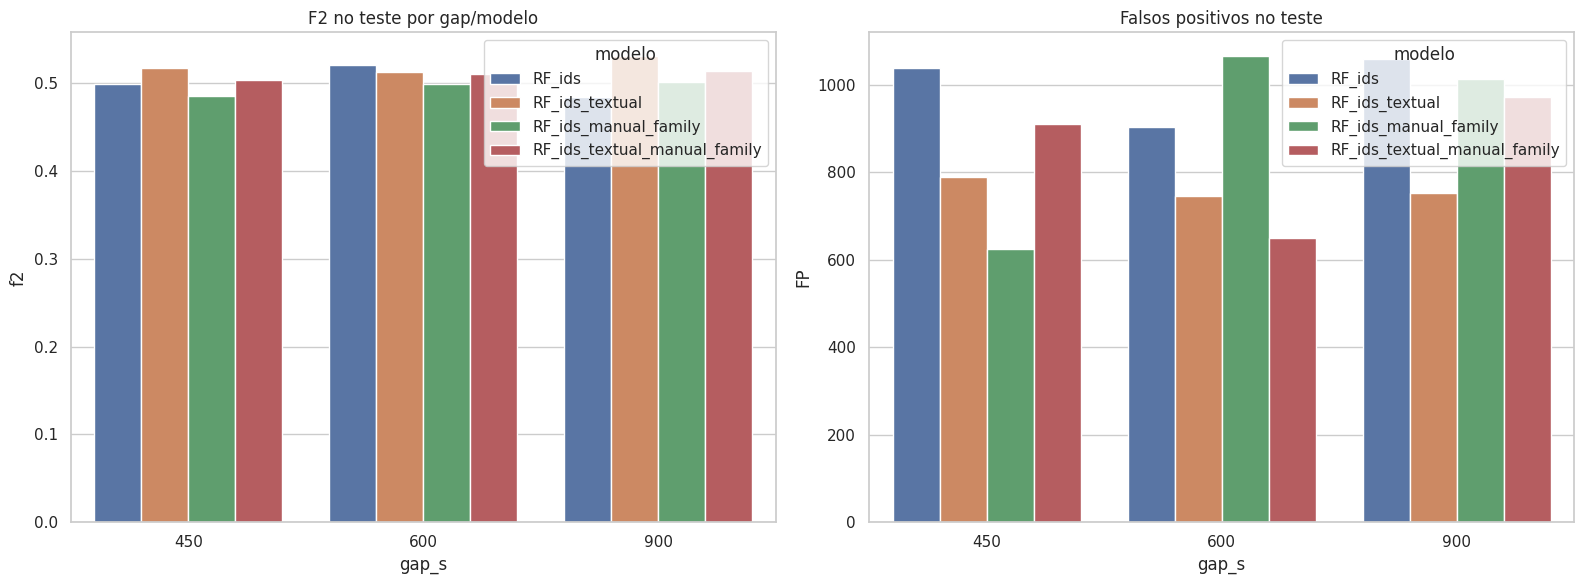

In [6]:
test_metrics = metrics[metrics["split"] == "teste"].copy()
validation_metrics = metrics[metrics["split"] == "validacao"].copy()

print("Teste - todos os modelos:")
display(test_metrics[[
    "gap_s", "modelo", "threshold", "pr_auc", "precision", "recall", "f2",
    "TP", "FP", "FN", "TN", "features", "tempo_s"
]].sort_values(["gap_s", "f2"], ascending=[True, False]))

print("Validação - todos os modelos:")
display(validation_metrics[[
    "gap_s", "modelo", "threshold", "pr_auc", "precision", "recall", "f2",
    "TP", "FP", "FN", "TN", "features"
]].sort_values(["gap_s", "f2"], ascending=[True, False]))

primary_test = test_metrics[test_metrics["gap_s"] == PRIMARY_GAP].sort_values("f2", ascending=False)
print(f"Gap principal {PRIMARY_GAP}s - ranking no teste:")
display(primary_test[[
    "modelo", "threshold", "pr_auc", "precision", "recall", "f2", "TP", "FP", "FN", "TN"
]])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=test_metrics, x="gap_s", y="f2", hue="modelo", ax=axes[0])
axes[0].set(title="F2 no teste por gap/modelo")
sns.barplot(data=test_metrics, x="gap_s", y="FP", hue="modelo", ax=axes[1])
axes[1].set(title="Falsos positivos no teste")
plt.tight_layout()
plt.show()

## 5. Leitura auditada

Critérios:

- o resultado principal deve ser lido no gap 900s;
- 450s e 600s servem como sensibilidade;
- se conceitos textuais continuarem superiores em 900s, eles seguem como melhor representação;
- se famílias manuais reduzirem FP com perda aceitável de recall, elas seguem como ferramenta de
  controle operacional;
- não escolher gap/modelo apenas pelo melhor teste isolado.